# Run this to enable loading from relative packes

In [1]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
    root_parent_level = 2
    import importlib, sys, pathlib # https://stackoverflow.com/a/50395128/11996983
    PKG = %pwd
    PKG = pathlib.Path(PKG)
    root = PKG
    full_pkg = f"{root.name}"
    for _ in range(root_parent_level):
        root = root.parent
        full_pkg = f"{root.name}.{full_pkg}"
        MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
        MODULE_NAME = f"{root.name}"
        spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
        module = importlib.util.module_from_spec(spec)
        sys.modules[spec.name] = module
        spec.loader.exec_module(module)
    __package__ = full_pkg


# Save plots with no embeded fonts

In [2]:
import matplotlib.pyplot as plt
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]


# Figures Save Path

In [3]:
save_prefix = r"../../results/RLModel/"
import pathlib
try:
    pathlib.Path(save_prefix).mkdir(exist_ok=True)
except:
    print("Failed to create save dir...")

# Common Imports

In [4]:
import numpy as np
import pandas as pd

# Define Analysis Parameters

In [5]:
# Analysis configuration.
#
# The models to evaluate are EvalSpec presets from model/aggregate.py: each is a
# (model_key, column_label) coordinate into the fits discovered on disk, so a
# figure never names a filename. See model/aggregate.py for the presets.
from .model.aggregate import (FIG1L_SPECS, SCALE_BOUND_SPECS, MLE_WEIGHT_SPECS,
                              CHI2_ONLY_RRQ_SPEC, MIN_NUM_TRIALS)
from .model.aggregate import N_PSYCH_FITS as _N_PSYCH_FITS_DEFAULT

# --- Evaluations -----------------------------------------------------------
# Collection is the slow step, so it is separated from plotting:
#
#   NUM_EVALUATIONS      how many simulations per subject to COLLECT (seeds
#                        0..N-1). Expensive -- roughly (specs x subjects x N)
#                        x ~2.5s -- but cached to disk, so you pay it once.
#   PLOT_NUM_EVALUATIONS how many of those to actually USE when plotting; must
#                        be <= NUM_EVALUATIONS. Iteration i is seed i and the
#                        seeds are independent, so the first n is a valid
#                        subsample. Change this and re-run only the plot cell.
#   FORCE_RECOMPUTE      ignore the cache and re-simulate. The cache also
#                        invalidates itself when a fit file is newer than it,
#                        when the specs change, or when N_PSYCH_FITS changes.
NUM_EVALUATIONS = 1_00
PLOT_NUM_EVALUATIONS = NUM_EVALUATIONS
FORCE_RECOMPUTE = False

# Psychometric multi-starts per fit. This is ~64% of the cost of one
# evaluation, so lowering it is the cheapest way to speed up an exploratory
# pass -- but it changes the fitted values, so leave it at the default for
# any figure that goes in the paper. It is part of the cache key.
N_PSYCH_FITS = _N_PSYCH_FITS_DEFAULT   # lower (e.g. 5) for a fast pass

assert PLOT_NUM_EVALUATIONS <= NUM_EVALUATIONS, (
    f"PLOT_NUM_EVALUATIONS={PLOT_NUM_EVALUATIONS} > "
    f"NUM_EVALUATIONS={NUM_EVALUATIONS}: cannot plot more than we collected.")

SAVE_FIGS = True

# Load all mice data

In [6]:
from .model import compare

# Loads + prepares the behavior dataframe exactly as the fitting code does
# (avg reward rate, size reduction, trial extension so every session has the
# same length, SessId/DVabs/Q/RewardRate columns).
df_behavior = compare.prepare_behavior_df()

TODO: EarlyWithdrawal trials are not included, results may differ


AttributeError: 'DataFrame' object has no attribute 'valid'

# Load Results

In [7]:
# Discover every saved fit on disk and index it by
# (model_key, column_label) -- the coordinate an EvalSpec addresses.
# model_key   = abstract model (drift alias + bias + noise + timing + asym)
# column_label= fitting criterion ("Chi2-Noise", "Chi2-Bound", "MLE", "MLE=1, Chi2=0.1", ...)
fits = compare.discover_fits()

Discovered 4 model(s), 80 subject×model combos.


In [8]:
# (getFitDict / runSubjectData used to live here. They are replaced by
#  model/aggregate.py's resolve_spec + model/compare.py's _compute_sim, which
#  route fitted params generically -- including fits where the frozen scale axis
#  (BOUND for a noise-scaled fit, NOISE_SIGMA for a scale-bound fit) is absent.)

## Ext. Fig. 5a-1st & 2nd columns

# Collect relevant data points

In [9]:
# (The reward-rate analysis constants moved to model/aggregate.py:
#  MIN_TRIALS_PER_SESS_RR, REWARD_RATE_NUM_PAST_TRIALS, REWARD_RATE_BY_SESS.)

In [8]:
from .model.aggregate import (load_or_collect_metrics, per_spec_frames,
                              rows_for_spec_from)

# One row per (model, subject, iteration), cached to disk under
# data/RLModel/metrics/. sim_cache collects the seed-0 simulation frame per
# model/subject for the per-subject figures below -- but ONLY on a real
# collection run: a cache hit does no simulation and leaves it empty.
sim_cache = {}
metrics_df = load_or_collect_metrics(
    fits, FIG1L_SPECS, df_behavior, cache_name="fig1l",
    num_evaluations=NUM_EVALUATIONS, n_psych_fits=N_PSYCH_FITS,
    force_recompute=FORCE_RECOMPUTE, sim_cache=sim_cache)
processed_df_dict = per_spec_frames(metrics_df)
display(metrics_df.head())

Loaded ..\..\data\RLModel\metrics\metrics_fig1l.pkl (100 evaluation(s); using 100).


,SpecLabel,ModelKey,ColumnLabel,Name,Iteration,Seed,NumTrials,R2_WinLose,R2_PrevOutcomeCount,PrevOutcomeCurQuantileReal,...,PsychReal,PsychModel,R2_Psych,R2_Slow,R2_Fast,R2_Total,WinStayReal,WinStayModel,LoseSwitchReal,LoseSwitchModel
0,Classic,"Classic|None_|Normal(0, 1)|4.8|0.005|sym",Chi²-Noise,Avgat1,0,0,3169,0.722428,0.122985,15.5765,...,-0.393170,0.006116,0.310185,0.975000,0.863688,1.838688,5.716688,0.449530,7.974684,10.249307
1,Classic,"Classic|None_|Normal(0, 1)|4.8|0.005|sym",Chi²-Noise,Avgat1,1,1,3169,0.823827,0.145773,15.5765,...,-0.445241,-0.056330,0.294248,0.997826,0.886088,1.883913,5.716688,1.913681,7.974684,9.256662
2,Classic,"Classic|None_|Normal(0, 1)|4.8|0.005|sym",Chi²-Noise,Avgat1,2,2,3169,0.713616,0.146776,15.5765,...,-0.383634,0.054689,0.257899,0.995412,0.846171,1.841583,5.716688,1.140385,7.974684,7.987220
3,Classic,"Classic|None_|Normal(0, 1)|4.8|0.005|sym",Chi²-Noise,Avgat1,3,3,3169,0.751006,0.135684,15.5765,...,-0.378596,-0.121611,0.210475,0.973190,0.878672,1.851863,5.716688,1.518260,7.974684,7.923497
4,Classic,"Classic|None_|Normal(0, 1)|4.8|0.005|sym",Chi²-Noise,Avgat1,4,4,3169,0.759715,0.241610,15.5765,...,-0.384457,0.139402,0.287979,0.972245,0.819787,1.792032,5.716688,1.327968,7.974684,8.625731


In [ ]:
from .model.aggregate import safe_filename


def plotCorrelations(analysis_df_dict, save_figs=False):
    subjects = df_behavior.Name.unique()
    subjects_colors = {subject: f"C{idx}"
                       for idx, subject in enumerate(subjects)}
    key_real_sim = ("WinStay", "LoseSwitch",
                    "MotorBiasAll", "MotorBiasFast", "MotorBiasSlow", "R2_PrevOutcomeQuantile",
                    "Psych", "PsychAbs", "R2_Psych", "R2_Total", "R2_Fast",)
    key_to_axs_li = {key: [] for key in key_real_sim}
    figs = []
    R2_TOTAL_MAX = 1 #.2
    for key, df in analysis_df_dict.items():
        print("Key:", key)
        model_name = key  # per_spec_frames keys by the EvalSpec label

        df = df.copy()
        df["Color"] = df.Name.apply(lambda x: subjects_colors[x])
        df["Marker"] = df.NumTrials.apply(
                lambda num_trials: "o" if num_trials >= MIN_NUM_TRIALS else "x")
        df = df[df.NumTrials >= MIN_NUM_TRIALS]
        # df = df[df.Name != "RDK_WT6"]

        fig, axs = plt.subplots(2, 6, figsize=(18, 7))
        fig.subplots_adjust(hspace=0.5, wspace=0.5)
        fig.suptitle(f"Model: {model_name} - Correlation Metrics Across Subjects",
                     fontsize=16)

        for ax, key in zip(axs.flatten(), key_real_sim):
            title = key if "Psych" not in key else f"{key} (Slow - Fast)"
            ax.set_title(title)
            if key in ("R2_Total", "R2_Psych", "R2_PrevOutcomeQuantile"):
                data = df[key].copy()
                if key == "R2_Total":
                    data /= 2
                # data = df["R2_Psych"].copy()
                # display(data)
                data = data.clip(0, R2_TOTAL_MAX)
                ax.scatter(df[key].index, data, c=df.Color)
                iqr_cols = []
            elif key in ("R2_Fast"):#, "R2_Slow"):
                for marker, marker_df in df.groupby("Marker"):
                    ax.scatter(marker_df["R2_Fast"], marker_df["R2_Slow"],
                               c=marker_df.Color, marker=marker)
                iqr_cols = []
            else:
                real_data, model_data = df[f"{key}Real"], df[f"{key}Model"]
                real_min, real_max = real_data.min(), real_data.max()
                above_limit = real_data > real_max
                below_limit = real_data < real_min
                within_limit = ~above_limit & ~below_limit
                model_data = model_data.clip(real_min, real_max)
                for marker, marker_df in df.groupby("Marker"):
                    marker_df_mask = df.index.isin(marker_df.index)
                    for mask, sub_marker in zip((within_limit, above_limit,  below_limit),
                                                (marker,       "^",          "v",)):
                        # if marker != "o":
                        #     print("Mask:", marker, "=", mask.sum())
                        ax.scatter(real_data[mask & marker_df_mask],
                                   model_data[mask & marker_df_mask],
                                   c=df.Color[mask & marker_df_mask],
                                   marker=sub_marker)
                iqr_cols = [f"{key}Real"]
                ax.set_xlabel("Real")
                ax.set_ylabel("Model")
                # Draw the 45 degree line
                ax.plot([0, 1], [0, 1], transform=ax.transAxes, ls="--",
                        c="gray", alpha=0.5)

            # We are using zip behavior of looping only until the shortest list
            for iqr_col, axlineFn in zip(iqr_cols, (ax.axvline, ax.axhline)):
                # Get real data IQR
                q_25, q_75 = df[iqr_col].quantile((.25, .75))
                iqr = q_75 - q_25
                iqr_limits = (q_25 - 1.5*iqr, q_75 + 1.5*iqr)
                x_lims = ax.get_xlim()
                if x_lims[0] < iqr_limits[0]:
                    axlineFn(iqr_limits[0], c="black", ls="--")
                if x_lims[1] > iqr_limits[1]:
                    axlineFn(iqr_limits[1], c="black", ls="--")
            key_to_axs_li[key].append(ax)
        # In the very last ax, plot each subject name, color and number of trials
        names_ax = axs.flatten()[-1]
        names_ax.axis("off")
        widths = []
        for idx, (_, row) in enumerate(df.iterrows()):
            names_ax.scatter(0*2, idx, c=row.Color, marker=row.Marker, s=15)
            text = names_ax.text(2, idx, f"{row.Name} - n={row.NumTrials:,}",
                                 color=row.Color, fontsize=5, va="center")
            # Get text width
            text_bb = text.get_window_extent()
            text_width = text_bb.width
            widths.append(text_width)
        max_width = max(widths)
        names_ax.set_xlim(-3, max_width + 3)
        names_ax.invert_yaxis()
        plt.draw()
        plt.show()
        figs.append(fig)
    # plt.close(fig)


    # Re-allign all the axes to have the same limits
    for key, axs_li in key_to_axs_li.items():
        if key not in ("R2_Total", "R2_Psych", "R2_PrevOutcomeQuantile"):
            x_lims = [ax.get_xlim() for ax in axs_li]
            # if key == "R2_Fast":
            #     x_lims += [ax.get_ylim() for ax in axs_li]
            min_x = min([lim[0] for lim in x_lims])
            max_x = max([lim[1] for lim in x_lims])
            if key == "R2_Fast":
                y_lims = [ax.get_ylim() for ax in axs_li]
            else:
                y_lims = x_lims
            min_y = min([lim[0] for lim in y_lims])
            max_y = max([lim[1] for lim in y_lims])
            for ax in axs_li:
                ax.set_xlim(min_x, max_x)
                ax.set_ylim(min_y, max_y)
        else:
            # Set only common y
            y_lims = [ax.get_ylim() for ax in axs_li]
            min_y = min([lim[0] for lim in y_lims])
            max_y = max([lim[1] for lim in y_lims])
            for ax in axs_li:
                ax.set_ylim(min_y, max_y)

        for ax in axs_li:
            if "R2" not in key:
                ax.set_aspect("equal", "box")

            ax.spines[["top", "right"]].set_visible(False)
            if key == "R2_Fast":
                ax.set_title("R2_Fast vs R2_Slow")
                ax.set_xlabel("R2_Fast")
                ax.set_ylabel("R2_Slow")


    if save_figs:
        for fig in figs:
            label = fig._suptitle.get_text()
            label = label.replace(":", "=")
            print("Saving:", label)
            fp = Path(f"{save_prefix}/{safe_filename(label)}_by_fixed_subj_color.svg")
            fp.parent.mkdir(exist_ok=True)
            fig.savefig(fp, bbox_inches="tight")

plotCorrelations(processed_df_dict, save_figs=SAVE_FIGS)

# Save or view models fits for the different subjects

In [ ]:
from .model.plotter import plotPlots, PsychometricPlot, createFig
from .model.aggregate import safe_filename
from pathlib import Path


def plotFitDfs(sim_cache, save_figs=False, plt_show=None, plt_agg=False):
    """Per-subject (and optionally across-subject) model-fit panels."""
    if plt_show is None:
        plt_show = not save_figs
    assert plt_show or save_figs, "Either plt_show or save_figs must be True"

    for model_name, subjects_dict in sim_cache.items():
        df_li = []
        for subject, (loss, fitted_df, BOUND, include_Q,
                      include_RewardRate) in subjects_dict.items():
            df_li.append(fitted_df)
            fig, axs = createFig(is_small_fig_mode=False)
            plotPlots(fitted_df, axs=axs, is_small_fig_mode=False,
                      BOUND=BOUND, include_Q=include_Q,
                      include_RewardRate=include_RewardRate,
                      psych_plot=PsychometricPlot.SlowFast,
                      plot_bias_dir=False, t_dur=T_DUR, dt=DT)
            fig.suptitle(f"Subject: {subject}\nModel: {model_name}\n"
                         f"Loss: {loss:.4f}", y=1.1)
            if save_figs:
                subj_dir = Path(f"{save_prefix}figs//{subject}")
                subj_dir.parent.mkdir(exist_ok=True)
                subj_dir.mkdir(exist_ok=True)
                fig.savefig(f"{subj_dir}/{safe_filename(model_name)}.svg",
                            bbox_inches="tight")
            if plt_show:
                plt.show()
            else:
                plt.close(fig)

        if not plt_agg:
            continue
        fig, axs = createFig(is_small_fig_mode=False)
        fig.suptitle(f"All Subjects\nModel: {model_name}", y=1.05)
        plotPlots(pd.concat(df_li), axs=axs, is_small_fig_mode=False,
                  BOUND=BOUND, include_Q=include_Q,
                  include_RewardRate=include_RewardRate,
                  psych_plot=PsychometricPlot.SlowFast,
                  plot_bias_dir=False, t_dur=T_DUR, dt=DT)
        if save_figs:
            subj_dir = Path(f"{save_prefix}figs/all_subjects")
            subj_dir.parent.mkdir(exist_ok=True)
            subj_dir.mkdir(exist_ok=True)
            fig.savefig(f"{subj_dir}/{safe_filename(model_name)}.svg",
                            bbox_inches="tight")
        if plt_show:
            plt.show()
        else:
            plt.close(fig)


# Timing of the fits being plotted (all presets are 4.8s / dt=0.005).
T_DUR, DT = 4.8, 0.005
# sim_cache is only filled by an actual collection run. On a metrics-cache hit
# there are no simulation frames to draw, so skip rather than fail.
if not sim_cache:
    print("sim_cache is empty (the metrics came from the disk cache). "
          "Re-run the collection cell with FORCE_RECOMPUTE = True to "
          "regenerate the per-subject simulation frames for this figure.")
else:
    plotFitDfs(sim_cache, save_figs=SAVE_FIGS, plt_show=False)


# Plot Aggregates

## Fig. 1l

OOB RewardRateCorr - 'Classic':
	Avgat1: 0.4371868429241526
	Rbp4_M2_1: -0.16909192820522714
OOB RewardRateCorr - 'RewardRate':
	GP4-85: -0.7092520003004159
OOB RewardRateCorr - 'RewardRate\n+ Q-Val':
	GP4-85: -0.36359142632384933


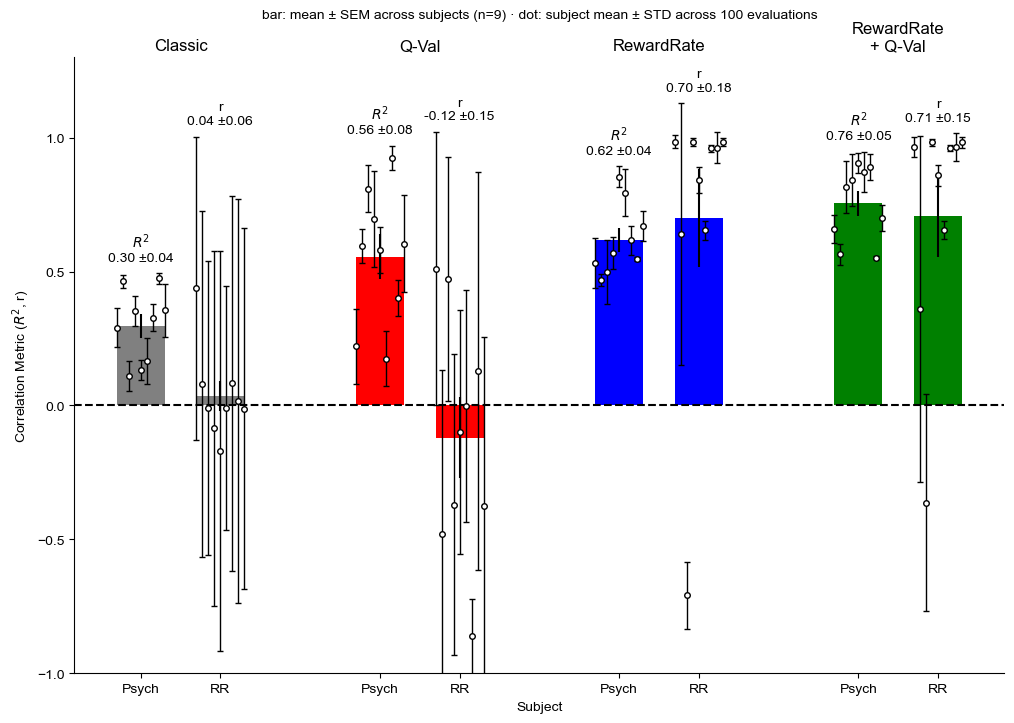

In [27]:
from .model.aggregate_plot import plot_aggregates

# Uses the first PLOT_NUM_EVALUATIONS of the collected iterations; re-running
# just this cell with a different value is cheap (no resimulation).
ax = plot_aggregates(metrics_df, FIG1L_SPECS,
                     num_evaluations=PLOT_NUM_EVALUATIONS)
if SAVE_FIGS:
    ax.figure.savefig(f"{save_prefix}/aggregates_R2_bar.svg",
                      bbox_inches="tight", dpi=300)

# Model Comparison: reward-rate implementation

Reward-rate as a **noise gain** (fixed threshold) vs. as a **scaled bound** (fixed noise), each without and with Q-Val — all from their Chi² fits. The two members of each pair are the *same* abstract model fitted under a different criterion, so they share a `model_key` and differ only in `column_label`. A half-column of space separates the no-Q-Val pair from the +Q-Val pair.

Evaluating 'RewardRate (Noise)\nFixed Threshold' (RewardRate|None_|Normal(0, 1)|4.8|0.005|sym / Chi²-Noise) — 20 subject(s) × 100 eval(s)


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychofit\psychofit.py:312: RuntimeWarning: divide by zero encountered in divide
  return gamma + (1 - 2 * gamma) * (erf((xx - bias) / slope) + 1) / 2
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychofit\psychofit.py:312: RuntimeWarning: divide by zero encountered in divide
  return gamma + (1 - 2 * gamma) * (erf((xx - bias) / slope) + 1) / 2
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychofit\psychofit.py:312: RuntimeWarning: divide by zero encountered in divide
  return gamma + (1 - 2 * gamma) * (erf((xx - bias) / slope) + 1) / 2
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychofit\psychofit.py:312: RuntimeWarning: divide by zero encountered in divide
  return gamma + (1 - 2 * gamma) * (erf((xx - bias) / slope) + 1) / 2
c:\Users\float\OneDrive - Floating Reality\D

  Subject Avgat2 has less than 2500 trials: 1653


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychofit\psychofit.py:312: RuntimeWarning: divide by zero encountered in divide
  return gamma + (1 - 2 * gamma) * (erf((xx - bias) / slope) + 1) / 2
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychofit\psychofit.py:312: RuntimeWarning: divide by zero encountered in divide
  return gamma + (1 - 2 * gamma) * (erf((xx - bias) / slope) + 1) / 2
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychofit\psychofit.py:312: RuntimeWarning: divide by zero encountered in divide
  return gamma + (1 - 2 * gamma) * (erf((xx - bias) / slope) + 1) / 2
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychofit\psychofit.py:312: RuntimeWarning: divide by zero encountered in divide
  return gamma + (1 - 2 * gamma) * (erf((xx - bias) / slope) + 1) / 2
c:\Users\float\OneDrive - Floating Reality\D

  Subject BVGAT1 has less than 2500 trials: 2145
  Subject GP4-24 has less than 2500 trials: 263
  Subject GP4-80 has less than 2500 trials: 1507
  Subject GP4-81 has less than 2500 trials: 2383


...

  Subject vgat-95 has less than 2500 trials: 1251


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychofit\psychofit.py:312: RuntimeWarning: divide by zero encountered in divide
  return gamma + (1 - 2 * gamma) * (erf((xx - bias) / slope) + 1) / 2
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychofit\psychofit.py:312: RuntimeWarning: divide by zero encountered in divide
  return gamma + (1 - 2 * gamma) * (erf((xx - bias) / slope) + 1) / 2
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychofit\psychofit.py:312: RuntimeWarning: divide by zero encountered in divide
  return gamma + (1 - 2 * gamma) * (erf((xx - bias) / slope) + 1) / 2
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychofit\psychofit.py:312: RuntimeWarning: divide by zero encountered in divide
  return gamma + (1 - 2 * gamma) * (erf((xx - bias) / slope) + 1) / 2
c:\Users\float\OneDrive - Floating Reality\D

  Subject vgat2.5 has less than 2500 trials: 2002


c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychofit\psychofit.py:312: RuntimeWarning: divide by zero encountered in divide
  return gamma + (1 - 2 * gamma) * (erf((xx - bias) / slope) + 1) / 2
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychofit\psychofit.py:312: RuntimeWarning: divide by zero encountered in divide
  return gamma + (1 - 2 * gamma) * (erf((xx - bias) / slope) + 1) / 2
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychofit\psychofit.py:312: RuntimeWarning: divide by zero encountered in divide
  return gamma + (1 - 2 * gamma) * (erf((xx - bias) / slope) + 1) / 2
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychofit\psychofit.py:312: RuntimeWarning: divide by zero encountered in divide
  return gamma + (1 - 2 * gamma) * (erf((xx - bias) / slope) + 1) / 2
c:\Users\float\OneDrive - Floating Reality\D

  Subject widefield_1 has less than 2500 trials: 826
Wrote ..\..\data\RLModel\metrics\metrics_scale_bound.pkl
OOB RewardRateCorr - 'RewardRate (Noise)\nFixed Threshold':
	GP4-85: -0.7092520003004159
OOB RewardRateCorr - 'RewardRate (Scale-Bound)\nFixed Noise':
	GP4-85: -0.655241722275872
OOB RewardRateCorr - 'RewardRate (Noise)\nFixed Threshold + Q-Val':
	GP4-85: -0.36359142632384933
OOB RewardRateCorr - 'RewardRate (Scale-Bound)\nFixed Noise + Q-Val':
	Avgat3: -0.5272127723661275
	GP4-85: -0.6250226625510187


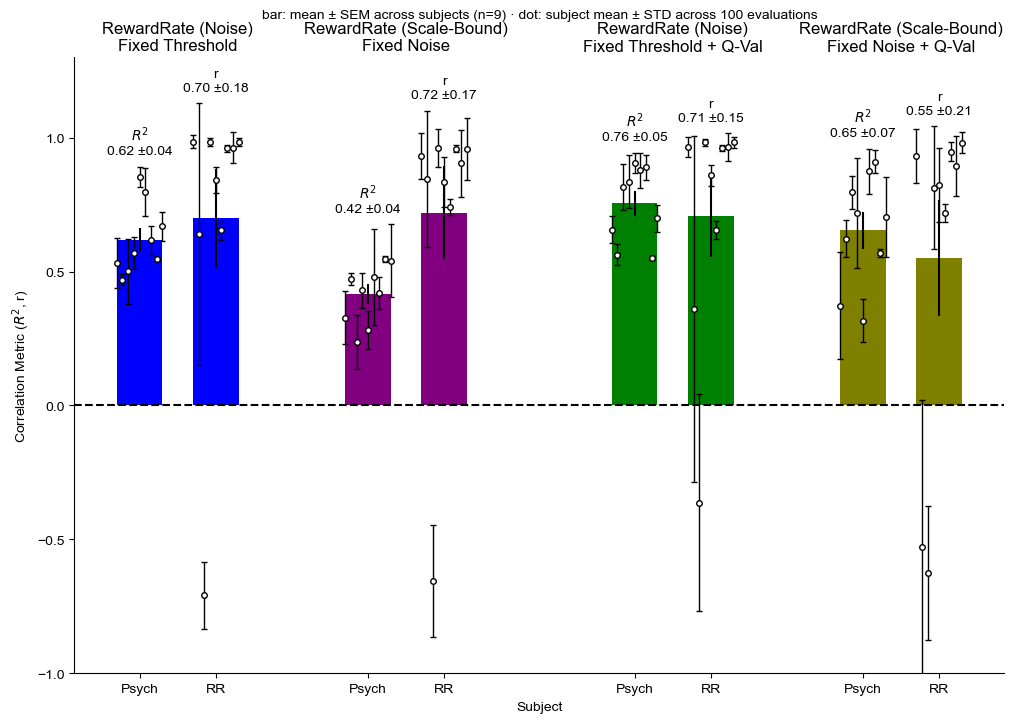

In [25]:
metrics_sb = load_or_collect_metrics(
    fits, SCALE_BOUND_SPECS, df_behavior, cache_name="scale_bound",
    num_evaluations=NUM_EVALUATIONS, n_psych_fits=N_PSYCH_FITS,
    force_recompute=FORCE_RECOMPUTE)
ax = plot_aggregates(metrics_sb, SCALE_BOUND_SPECS,
                     num_evaluations=PLOT_NUM_EVALUATIONS)
if SAVE_FIGS:
    ax.figure.savefig(f"{save_prefix}/aggregates_R2_scale_bound.svg",
                      bbox_inches="tight", dpi=300)

# Model Comparison: fitting criterion

One model — reward-rate (noise gain) + Q-Val — across fitting criteria: a **Chi²-only** reference first (its Chi²-Noise fit, reused from the Fig. 1l collection — not recomputed), then pure MLE (Chi² weight 0), joint MLE + Chi²=0.1, and joint MLE + Chi²=0.5. All share a `model_key`; only the `column_label` differs.

Loaded ..\..\data\RLModel\metrics\metrics_mle_weights.pkl (100 evaluation(s); using 100).
OOB RewardRateCorr - 'Chi²-only':
	GP4-85: -0.36359142632384933
OOB RewardRateCorr - 'MLE + Chi²=0.1':
	GP4-85: -0.588231217857627
OOB RewardRateCorr - 'MLE + Chi²=0.5':
	GP4-85: -0.48112248040282296


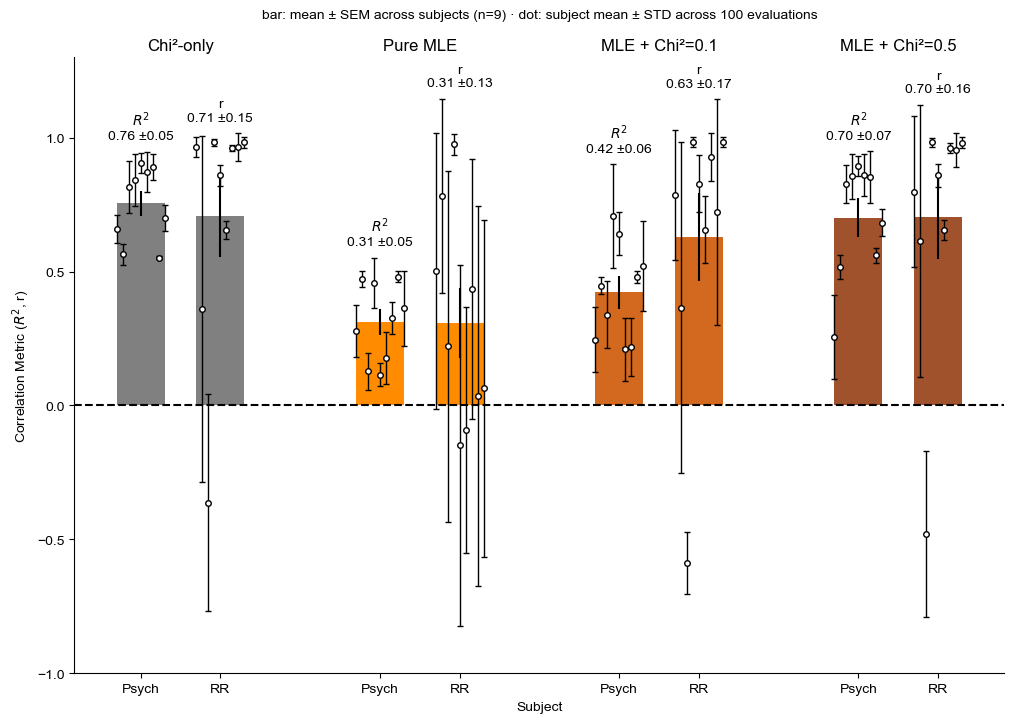

In [12]:
from .model.aggregate_plot import plot_aggregates

metrics_mle = load_or_collect_metrics(
    fits, MLE_WEIGHT_SPECS, df_behavior, cache_name="mle_weights",
    num_evaluations=NUM_EVALUATIONS, n_psych_fits=N_PSYCH_FITS,
    force_recompute=FORCE_RECOMPUTE)
# Prepend a Chi²-only reference column. Its fit is this same model's
# Chi²-Noise column, already collected for Fig. 1l -- borrow those rows
# from that frame (relabeled) instead of re-simulating them.
chi2_rows = rows_for_spec_from(metrics_df, CHI2_ONLY_RRQ_SPEC)
metrics_mle_full = pd.concat([chi2_rows, metrics_mle], ignore_index=True)

ax = plot_aggregates(metrics_mle_full, [CHI2_ONLY_RRQ_SPEC, *MLE_WEIGHT_SPECS],
                     num_evaluations=PLOT_NUM_EVALUATIONS)
if SAVE_FIGS:
    ax.figure.savefig(f"{save_prefix}/aggregates_R2_mle_weights.svg",
                      bbox_inches="tight", dpi=300)

# Plot aggregates where each subject has distinct color

In [ ]:
def _filterDF(df, min_num_trials, subjects_colors):
    df = df[df.NumTrials >= min_num_trials].copy()
    df["Color"] = df.Name.apply(lambda x: subjects_colors[x])
    return df


def plotAggregatesBySubjColor(analysis_df_dict, specs, save_figs=False):
    """Same aggregates as Fig. 1l, but one distinct colour per subject."""
    subjects = df_behavior.Name.unique()
    subjects_colors = {subject: f"C{idx}" for idx, subject in enumerate(subjects)}

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Correlation Aggregates")
    dfs_keys = ("R2_Psych", "RewardRateCorr", "R2_WinLose")
    markers = ("o", "s", "^", "D", "v", "P")

    for ax, key in zip(axs.flatten(), dfs_keys):
        ax.set_title("Reward Rate Pearson Corr"
                     if key == "RewardRateCorr" else key)
        offset_x = 0
        for spec, marker in zip(specs, markers):
            df = _filterDF(analysis_df_dict[spec.label], MIN_NUM_TRIALS,
                           subjects_colors)
            data = df[key]
            data_iqr = data.quantile([.25, .75])
            iqr = data_iqr[.75] - data_iqr[.25]
            OOB_mask = ((data < data_iqr[.25] - 1.5*iqr) |
                        (data > data_iqr[.75] + 1.5*iqr))
            if OOB_mask.any():
                print(f"OOB {key} - {spec.label}:")
                for idx, row in data[OOB_mask].items():
                    print(f"\t{df.Name.loc[idx]}: {row}")
            data = data[~OOB_mask]
            x_rng = np.arange(len(data))
            ax.plot(offset_x + x_rng, data.mean()*np.ones_like(x_rng),
                    c=spec.color, ls="--")
            ax.scatter(offset_x + x_rng, data, c=df[~OOB_mask].Color.values,
                       label=spec.label.replace("\n", " "), s=15, marker=marker)
            offset_x += len(x_rng) + 3
            if spec is not specs[-1]:
                ax.axvline(offset_x - 1.5, c="gray", ls="--")
        ax.set_xlabel("Subject")
        ax.set_ylabel("R2" if "R2" in key else "Pearson Corr")
        ax.set_ylim(-1 if key == "RewardRateCorr" else 0, 1.1)
        ax.set_xticks([])
        ax.spines[["top", "right"]].set_visible(False)
    ax.legend(loc="lower left", bbox_to_anchor=(.9, 0), fontsize="xx-small",
              ncols=1)
    plt.draw()

    if save_figs:
        fig.savefig(f"{save_prefix}/aggregates_R2_subj_color.svg",
                    bbox_inches="tight")


plotAggregatesBySubjColor(processed_df_dict, FIG1L_SPECS, save_figs=SAVE_FIGS)

# Prev. Outcome by Animal"s session and Timeout Punishment

# Ext. Fig. 5a-right

In [ ]:
from .model.plotter import _plotPrevOutcomeQuantile


def loopModelSubjectsPlotPrevOutcomeCount(sim_cache, df_behavior,
                                          save_figs=False):
    model_names = list(sim_cache)
    for subject, subject_df in df_behavior.groupby("Name"):
        if len(subject_df[subject_df.valid]) < MIN_NUM_TRIALS:
            continue
        fig, axs = plt.subplots(nrows=len(model_names), ncols=1,
                                figsize=(8, 5*len(model_names)))
        for model_name, ax in zip(model_names, np.atleast_1d(axs).flatten()):
            if subject not in sim_cache[model_name]:
                continue
            loss, fitted_df, BOUND, include_Q, include_RewardRate = \
                                                sim_cache[model_name][subject]
            _plotPrevOutcomeQuantile(fitted_df, ax=ax, annotate_fast_slow=True)
            ax.set_title(f"Subject: {subject} - {model_name}\n" + ax.get_title())
        if save_figs:
            fp = pathlib.Path(f"{save_prefix}/StrategyByPrevCorrect/{subject}.svg")
            fp.parent.mkdir(exist_ok=True)
            fig.savefig(fp, bbox_inches="tight", dpi=300)
        plt.show()


# sim_cache is only filled by an actual collection run. On a metrics-cache hit
# there are no simulation frames to draw, so skip rather than fail.
if not sim_cache:
    print("sim_cache is empty (the metrics came from the disk cache). "
          "Re-run the collection cell with FORCE_RECOMPUTE = True to "
          "regenerate the per-subject simulation frames for this figure.")
else:
    loopModelSubjectsPlotPrevOutcomeCount(sim_cache, df_behavior,
                                          save_figs=SAVE_FIGS)


# Plot Avg. Reward Rate

## Fig. 1k, Ext. Fig. 5a-3rd column

In [ ]:
from ..behavior.rewardrate import loopRewardRateAnalysis

def loopSubjectModels(processed_dict, df_behavior, subject_name=None,
                      save_figs=False):

    if subject_name is not None:
        df_behavior = df_behavior[df_behavior.Name == subject_name]

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    loop_kwargs = dict(
        plot_singles_on_all=False, plot_subjects=False, ax_all=ax,
        exclude_reward_rate_bins=[0], run_stats=False,
        min_trials_per_sess_rr=MIN_TRIALS_PER_SESS_RR,
        ax_all_used_timeout_time="All"
    )
    loopRewardRateAnalysis(df_behavior,
                           descrp="Behavior", #print_only_sim=True,
                           **loop_kwargs)
    for comb_str, comb_dict in processed_dict.items():
        # sim_cache is keyed by the EvalSpec label.
        # loss, fitted_df, BOUND, include_Q, include_RewardRate
        subjects_dict = {subject:fitted_df  for subject,
                        (loss, fitted_df, BOUND, include_Q, include_RewardRate) in comb_dict.items()
                        if subject_name is None or subject == subject_name
            }
        df_subjects = pd.concat(subjects_dict.values())
        loopRewardRateAnalysis(df_subjects, descrp=comb_str, print_only_sim=True,
                                **loop_kwargs)

    ax.axhline(0, color="gray", linestyle="--", alpha=0.3, zorder=-1)
    ax.spines[["top", "right"]].set_visible(False)
    # ax.set_ylim(bottom=-0.6, top=1.5)
    ax.legend(loc="upper right", fontsize="small")

    ax.set_title("All Subjects" if subject_name is None else f"Subject: {subject_name}")
    if save_figs:
        label = f"subject_{subject_name}" if subject_name is not None else "all_subjects"
        fp = pathlib.Path(f"{save_prefix}/RewardRate/{label}.svg")
        fp.parent.mkdir(exist_ok=True)
        print("Saving:", label)
        fig.savefig(fp, bbox_inches="tight")
    plt.show()



def loopModels(processed_dict, df_behavior,
               plot_subjects=False, save_figs=False):
    df_behavior = df_behavior.groupby("Name").filter(
                                             lambda x: len(x) >= MIN_NUM_TRIALS)

    df_behavior["SessId"] = df_behavior.Name + "_" + \
                            df_behavior.Date.astype(str) + "_" + \
                            df_behavior.SessionNum.astype(str)
    loopSubjectModels(processed_dict, df_behavior=df_behavior,
                      subject_name=None,
                      save_figs=save_figs)
    if plot_subjects:
        for subject in df_behavior.Name.unique():
            loopSubjectModels(processed_dict, df_behavior=df_behavior,
                              subject_name=subject,
                              save_figs=save_figs)

# sim_cache is only filled by an actual collection run. On a metrics-cache hit
# there are no simulation frames to draw, so skip rather than fail.
if not sim_cache:
    print("sim_cache is empty (the metrics came from the disk cache). "
          "Re-run the collection cell with FORCE_RECOMPUTE = True to "
          "regenerate the per-subject simulation frames for this figure.")
else:
    loopModels(sim_cache,
               df_behavior[df_behavior.valid].copy(),
               plot_subjects=True, save_figs=SAVE_FIGS)
